# Simple Logisitic Regression

In [1]:
import sklearn
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
from sklearn.datasets import load_breast_cancer
df = load_breast_cancer(as_frame = True).frame 
df["target"].value_counts( )

target
1    357
0    212
Name: count, dtype: int64

In [3]:
df.head() 

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
X= df[['mean radius'] ]
y = df['target']


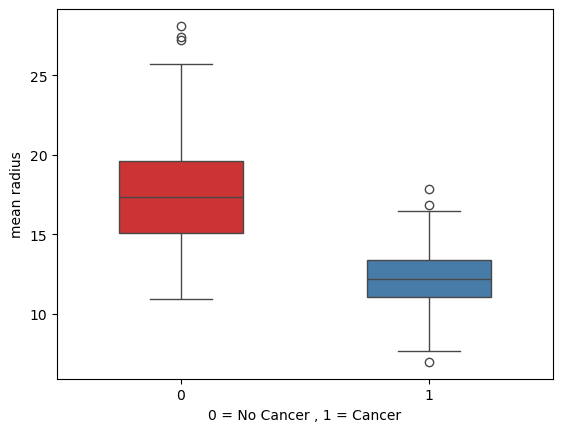

In [5]:
plt.figure() 
sns.boxplot(y=df['mean radius'],x= df['target'], hue=y, palette="Set1", legend=False, width = 0.5)
plt.xlabel ( '0 = No Cancer , 1 = Cancer' )
plt.show()

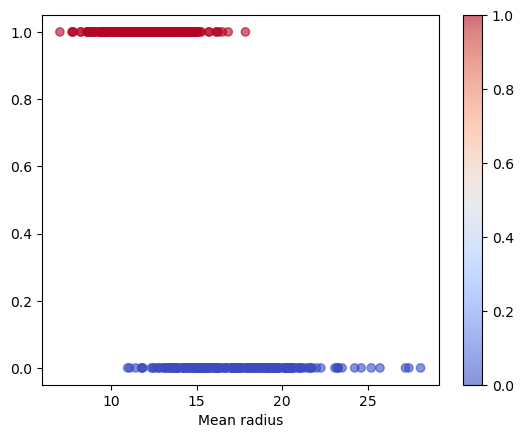

In [6]:
plt.figure( )
plt.scatter(df['mean radius'], df['target'], c=df['target'], cmap='coolwarm', alpha=0.6)
plt.colorbar()
plt.xlabel('Mean radius' ) 
plt.show() 

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split ,cross_val_score

pipeline = Pipeline ( [
    ( 'scaling' , StandardScaler() ) ,
    ('model', LogisticRegression() )
]
                    )

X_train ,X_test, y_train , y_test = train_test_split( X,
                                                      y, 
                                                      stratify=y ,
                                                      random_state=26,
                                                      shuffle=True,
                                                      test_size= 0.2 ) 

In [8]:
scores = cross_val_score( pipeline, X_train , y_train , cv = 10, scoring= 'accuracy' ) 
scores.mean() 

np.float64(0.8770531400966185)

In [9]:
scores = cross_val_score( pipeline, X_train , y_train , cv = 10, scoring= 'neg_log_loss' ) 
-scores.mean() 

np.float64(0.28976382119237987)

In [10]:
pipeline.fit(X_train , y_train)

,steps,"[('scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [11]:
model = pipeline.named_steps['model']

In [12]:
model.intercept_

array([0.63610878])

In [13]:
model.coef_

array([[-3.29833934]])

In [14]:
model.n_iter_

array([7], dtype=int32)

In [15]:
pipeline.score(X_train, y_train)

0.8791208791208791

In [16]:
pipeline.score(X_test, y_test)

0.8859649122807017

In [17]:
np.round(pipeline.predict_proba(X_test[:5]) ,3)

array([[0.787, 0.213],
       [0.083, 0.917],
       [0.908, 0.092],
       [0.994, 0.006],
       [0.294, 0.706]])

In [18]:
X_test[:5]

,mean radius
132,16.16
200,12.23
72,17.20
321,20.16
125,13.85


# Multi logistic regression 

In [19]:
df = pd.read_csv("C:/users/hp/downloads/student_performance_dataset.csv") 
df.head(5)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [20]:
df.isna().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [22]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


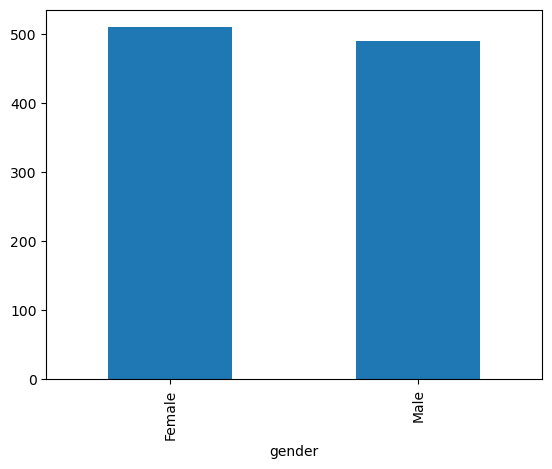

In [23]:
df['gender'].value_counts().plot(kind='bar')
plt.show()

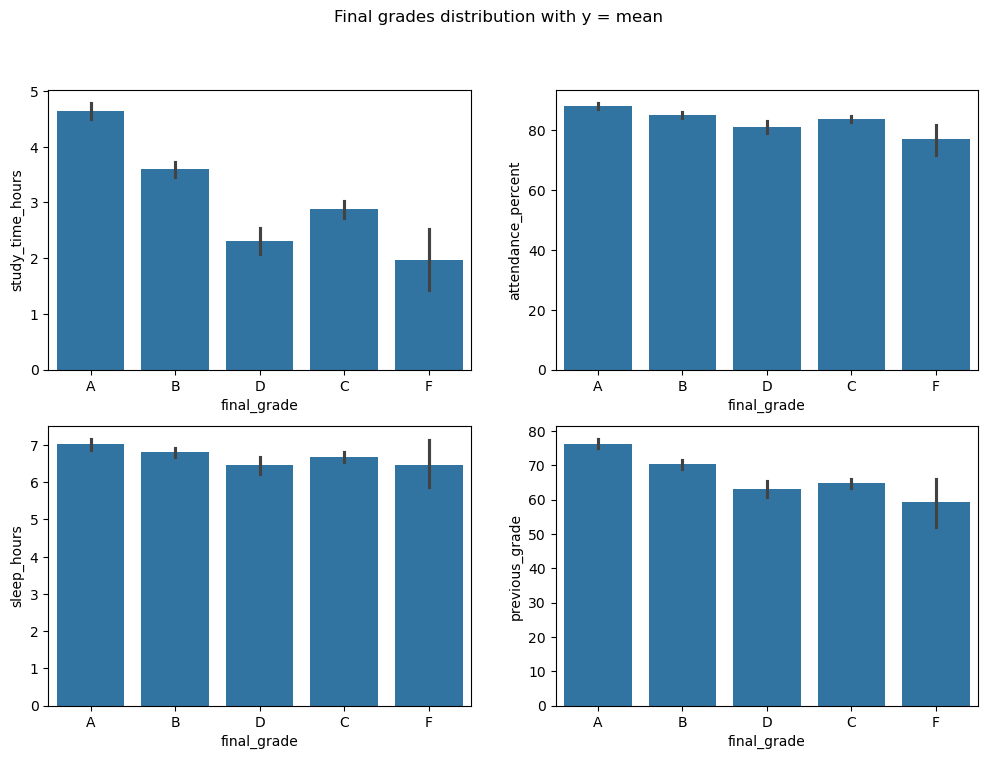

In [24]:
cols = ['study_time_hours' , 'attendance_percent' , 'sleep_hours' , 'previous_grade' ]
fig , ax = plt.subplots( 2,2 , figsize= (12,8))
ax = ax.flatten()
for idx , val in enumerate( cols ) : 
    sns.barplot(data=df, x='final_grade', y= val , ax = ax[idx] , estimator= 'mean' )
plt.suptitle('Final grades distribution with y = mean')
plt.show()
    

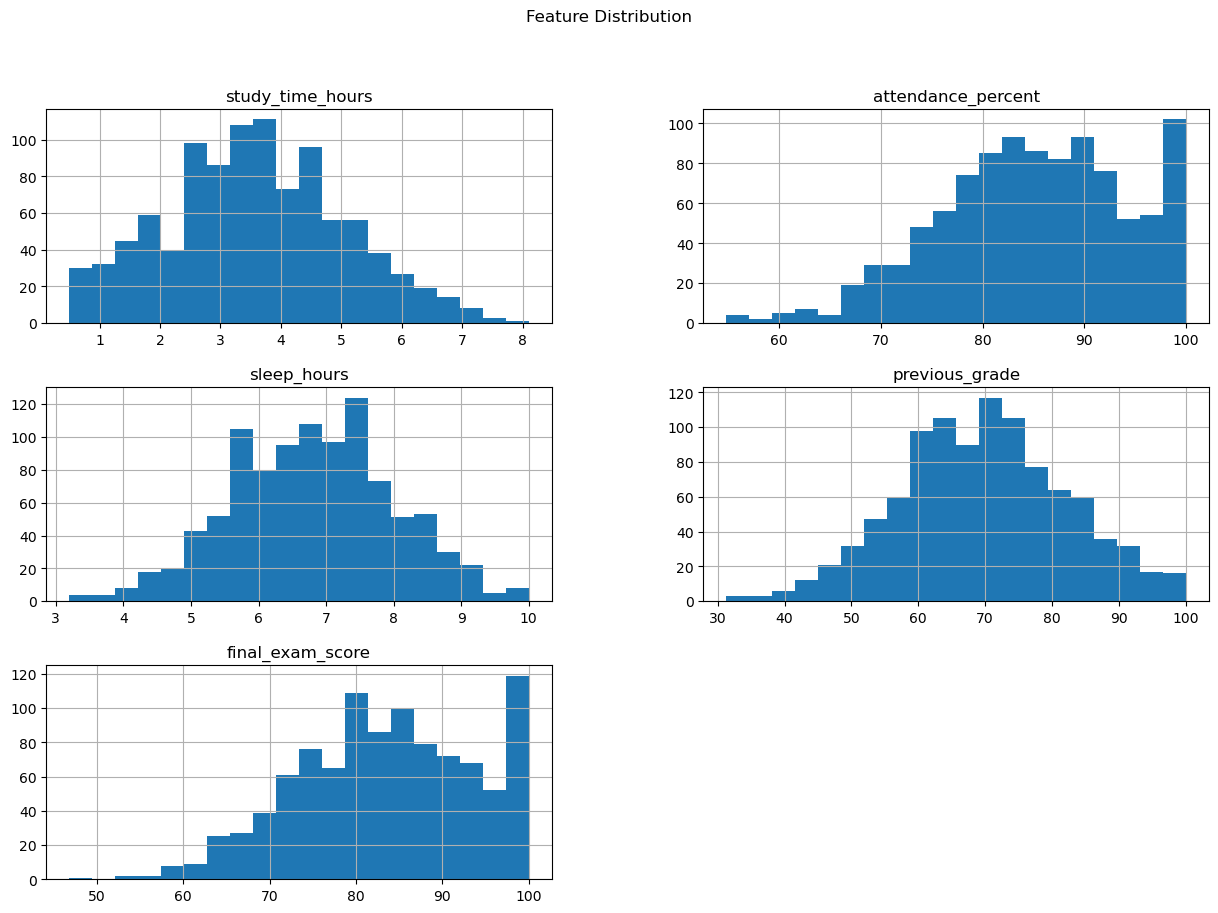

In [25]:
cols = [ 'study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade' , 'final_exam_score' ] 

df[cols].hist( figsize=(15,10) , bins = 20 )
plt.suptitle('Feature Distribution')
plt.show( )

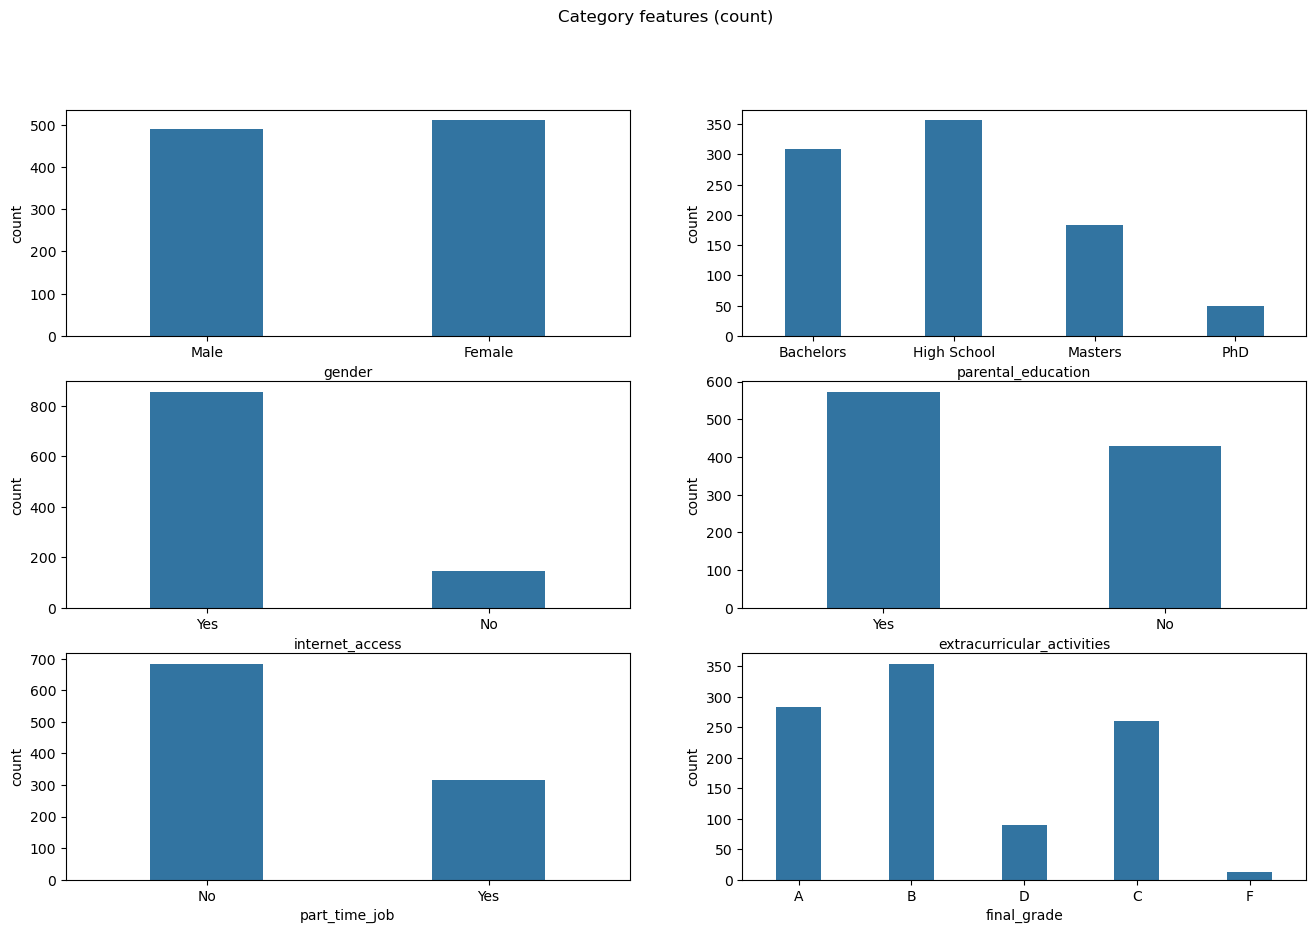

In [26]:
catg = df.select_dtypes(include=['object', 'category']).columns.tolist()


fig , ax = plt.subplots( 3,2 , figsize= (16,10))
ax = ax.flatten()
for idx , val in enumerate( catg ) : 
    sns.countplot( data = df , x=val , ax = ax[idx] , width=0.4, )
plt.suptitle('Category features (count)')
plt.show()
    

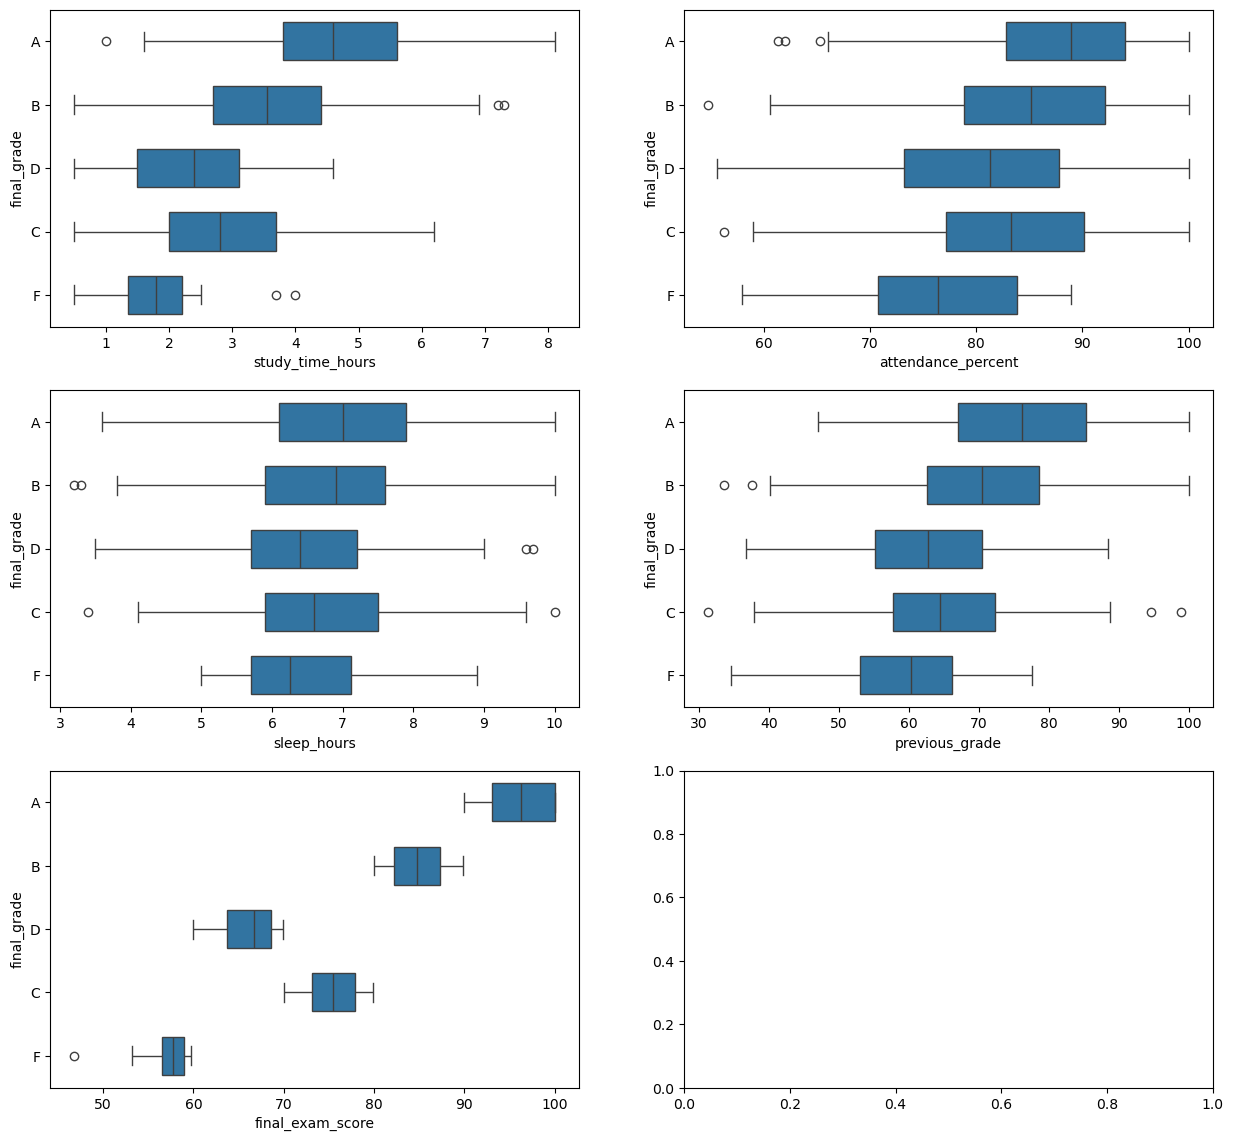

In [27]:
num  = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
del num [0]
fig , ax = plt.subplots( 3,2 , figsize= (15,14))
ax = ax.flatten()
for idx , val in enumerate( num ) : 
    sns.boxplot( data = df , y='final_grade' , x= val , orient='h', ax = ax[idx] , width =0.6 )
plt.show()

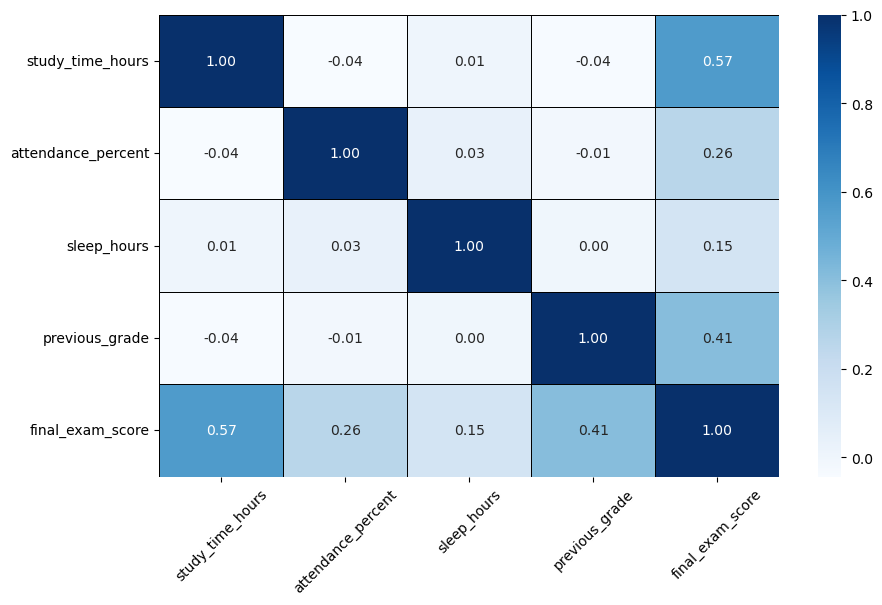

In [28]:
corr = df[num].corr() 
plt.figure( figsize = (10,6)) 
sns.heatmap(corr,cmap  = 'Blues' , annot = True , linewidth = 0.5,linecolor='black' , fmt ='.2f')
plt.xticks(rotation=45) 
plt.show()

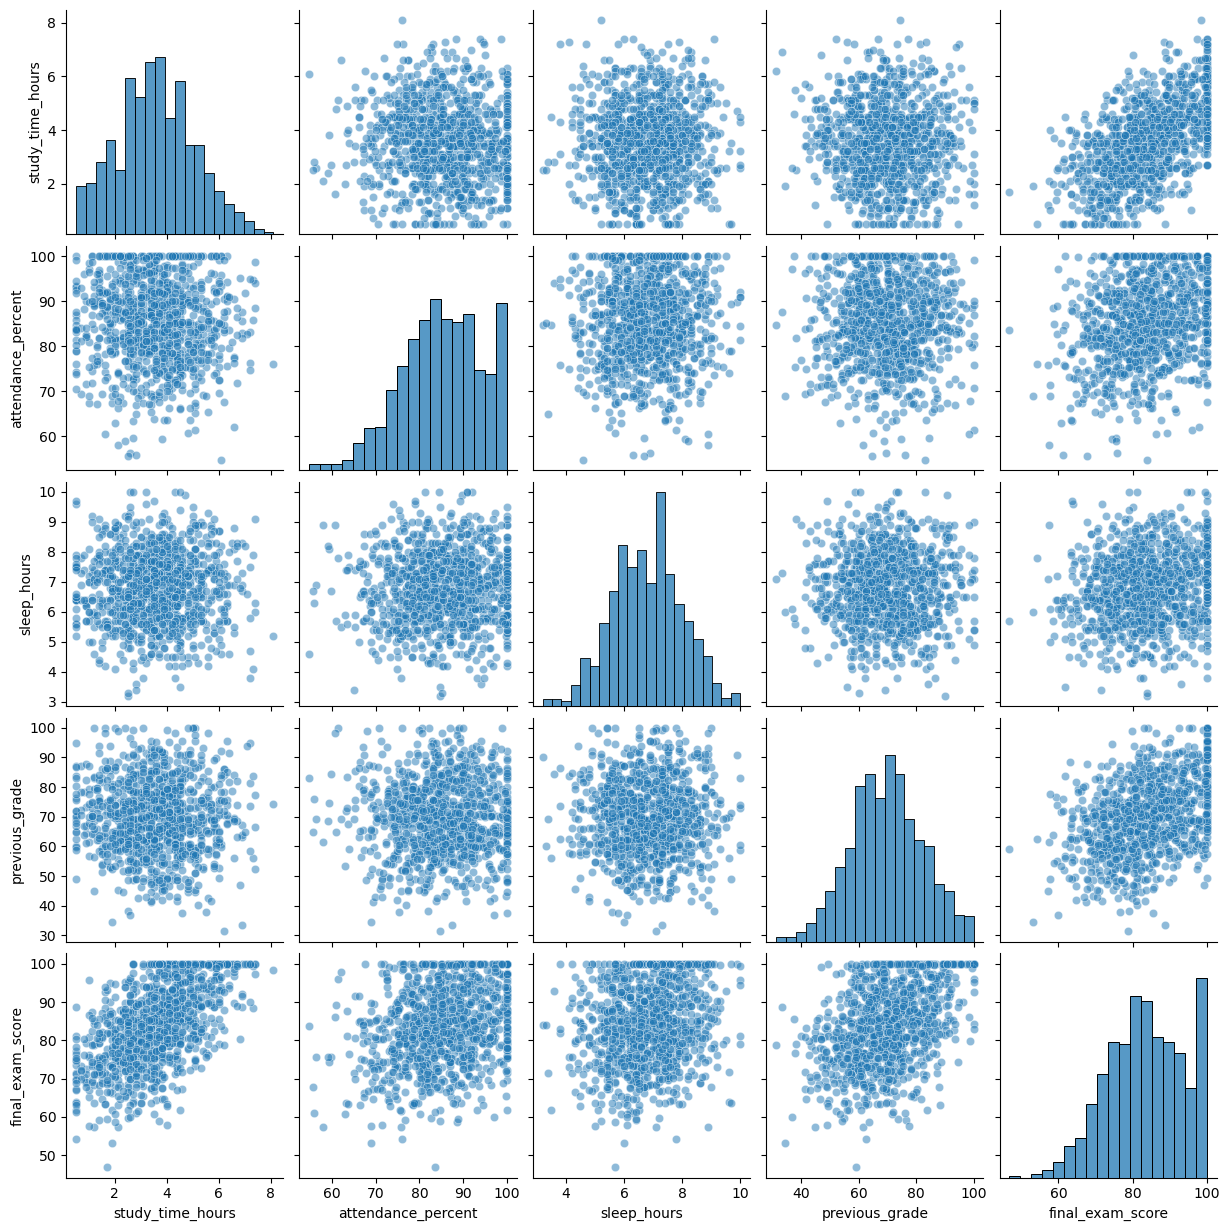

In [29]:
sns.pairplot ( df [num] , plot_kws={'alpha': 0.5} ) 
plt.show()

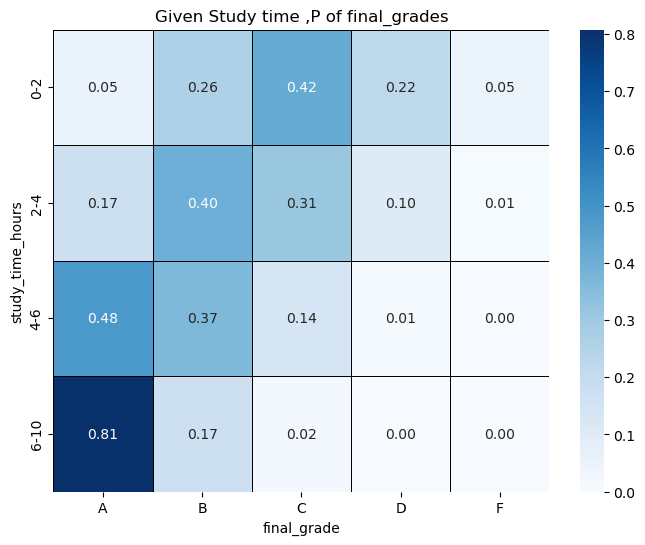

In [30]:
study_ = pd.cut( df['study_time_hours'] , bins  = [0 ,2 ,4,6, 10 ] , labels = ['0-2' , '2-4' , '4-6', '6-10'] ) 

cross = pd.crosstab( study_ , df['final_grade'] , normalize = 'index') 

plt.figure(figsize = (8,6)) 
plt.title('Given Study time ,P of final_grades' )
sns.heatmap(cross , cmap = 'Blues' , annot = True , linewidth = 0.5,linecolor='black' , fmt ='.2f')
plt.show()

In [31]:
num, catg

(['study_time_hours',
  'attendance_percent',
  'sleep_hours',
  'previous_grade',
  'final_exam_score'],
 ['gender',
  'parental_education',
  'internet_access',
  'extracurricular_activities',
  'part_time_job',
  'final_grade'])

In [32]:
df['pass'] = df['final_grade'].isin(['A', 'B', 'C']).astype(int)
X  = df.drop(['pass', 'final_exam_score' ,'final_grade' , 'student_id'], axis  =1 )
y  = df['pass']

numeric  = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
category = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [33]:
nominal = ['gender' , 'internet_access' , 'extracurricular_activities' , 'part_time_job']
ordinal = ['parental_education']

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split ,cross_val_score
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder , LabelEncoder
from sklearn.impute import SimpleImputer

preprocess = ColumnTransformer ( [
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric),
    
    ('nominal', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop = None))
    ]), nominal),
    
    ('ordinal', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=[['High School', 'Bachelors', 'Masters', 'PhD']]))
    ]), ordinal)
    
])

X_train , X_test , y_train ,y_test = train_test_split( X,y , random_state=26 ,stratify = y, test_size = 0.2 , shuffle = True )


In [35]:
X_train_transformed = preprocess.fit_transform(X_train) 
model = LogisticRegression()
model.fit(X_train_transformed , y_train) 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
feature_names = preprocess.get_feature_names_out()
pd.Series( model.coef_[0] , index = feature_names).sort_values(ascending = False)

num__study_time_hours                      1.886278
num__previous_grade                        1.333896
num__attendance_percent                    0.966980
nominal__part_time_job_No                  0.662571
nominal__internet_access_Yes               0.623804
num__sleep_hours                           0.516101
ordinal__parental_education                0.396575
nominal__gender_Male                       0.062877
nominal__extracurricular_activities_Yes    0.006323
nominal__extracurricular_activities_No    -0.003505
nominal__gender_Female                    -0.060059
nominal__internet_access_No               -0.620987
nominal__part_time_job_Yes                -0.659753
dtype: float64

The probability of passing exams is heavily dependent on studytime, previous_grads ,attendace etc and while gender did contrbiute but not too much 


and the having no internet access and part time job during studies decreases the probability of passing the exams

In [37]:
scores = cross_val_score(model, X_train_transformed ,y_train , scoring = 'accuracy' , cv  = 5)
scores.mean() , scores.std()

(np.float64(0.9137500000000001), np.float64(0.015000000000000029))

In [38]:
scores = cross_val_score(model, X_train_transformed ,y_train , scoring = 'neg_log_loss' , cv  = 5)
-scores.mean() , scores.std()

(np.float64(0.20337116761182578), np.float64(0.031227927332992463))

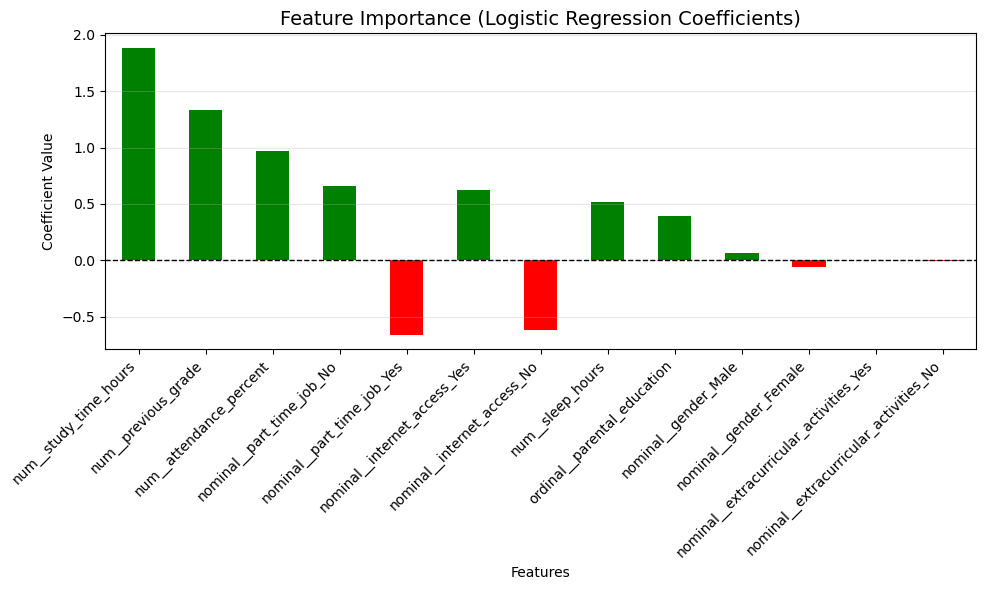

In [39]:
feature_names = preprocess.get_feature_names_out()
coef_series = pd.Series(model.coef_[0], index=feature_names)
coef_sorted = coef_series.sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
coef_sorted.plot(kind='bar', color=['green' if c > 0 else 'red' for c in coef_sorted])
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Feature Importance (Logistic Regression Coefficients)', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [40]:
model.score(X_train_transformed, y_train)

0.9175

In [41]:
model.score(preprocess.transform(X_test), y_test)

0.935

Somewhat stable model

In [42]:

sample = preprocess.transform(X_test.iloc[26:30])


predictions = model.predict(sample)
print("Predictions:", predictions)
print("Actual labels:", y_test.iloc[26:30].values)

Predictions: [1 1 1 0]
Actual labels: [1 1 1 0]


In [43]:
model.predict_proba( sample)

array([[0.0116973 , 0.9883027 ],
       [0.00286207, 0.99713793],
       [0.00692888, 0.99307112],
       [0.69030906, 0.30969094]])

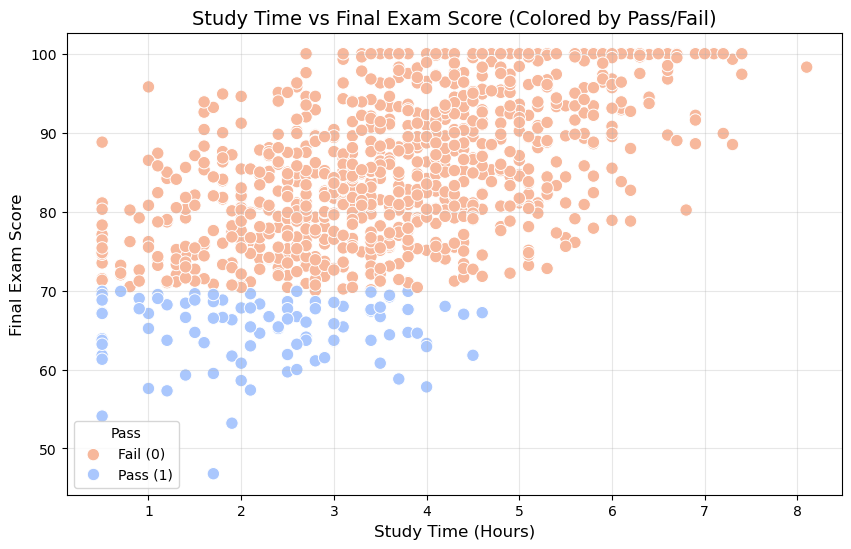

In [44]:
plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
    data=df,
    x='study_time_hours',
    y='final_exam_score',
    hue='pass',           
    palette='coolwarm',   
    alpha=1,
    s=80                  
)


plt.xlabel('Study Time (Hours)', fontsize=12)
plt.ylabel('Final Exam Score', fontsize=12)
plt.title('Study Time vs Final Exam Score (Colored by Pass/Fail)', fontsize=14)

plt.legend(title='Pass', labels=['Fail (0)', 'Pass (1)'], loc='best')
plt.grid(True, alpha=0.3)
plt.show()

We can apply linear regression here as well

In [56]:
from sklearn.linear_model import LinearRegression

X = df.drop ( columns = [ 'student_id' , 'final_grade' , 'pass' ] )
y = df['final_exam_score']


preprocess_2 = ColumnTransformer ( [
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric),
    
    ('nominal', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop = None))
    ]), nominal),
    
    ('ordinal', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=[['High School', 'Bachelors', 'Masters', 'PhD']]))
    ]), ordinal)
    
])

model_2 = LinearRegression()
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split( X,y , test_size=0.2 , random_state=26, shuffle = True) 

X_train_transformed_2 = preprocess_2.fit_transform(X_train_2)

In [57]:
model_2.fit(X_train_transformed_2,y_train_2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
lin_coef = pd.Series ( model_2.coef_ , preprocess_2.get_feature_names_out() )
lin_coef

num__study_time_hours                      6.096483
num__attendance_percent                    2.957709
num__sleep_hours                           1.464358
num__previous_grade                        4.511377
nominal__gender_Female                     0.040140
nominal__gender_Male                      -0.040140
nominal__internet_access_No               -2.647635
nominal__internet_access_Yes               2.647635
nominal__extracurricular_activities_No    -0.447399
nominal__extracurricular_activities_Yes    0.447399
nominal__part_time_job_No                  1.565342
nominal__part_time_job_Yes                -1.565342
ordinal__parental_education                0.286674
dtype: float64

One studytimehour increases 6 marks in the exams

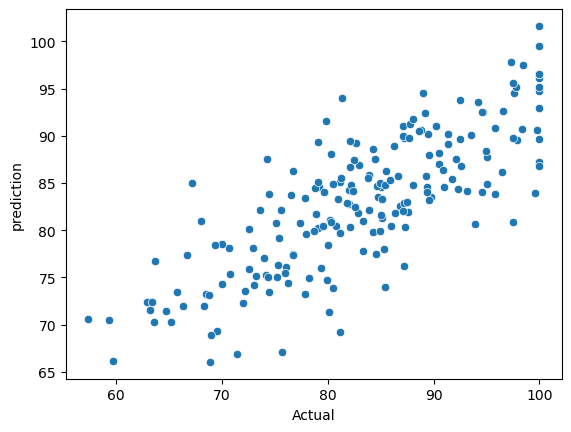

In [59]:
sns.scatterplot( x=  y_test_2 , y = model_2.predict( preprocess_2.transform(X_test_2) ) )
plt.xlabel('Actual')
plt.ylabel('prediction')
plt.show()

In [60]:
model_2.score(X_train_transformed_2, y_train_2) 

0.6724472550678193

In [61]:
model_2.score( preprocess_2.transform(X_test_2) , y_test_2) 

0.630158250771359

Generalizes well

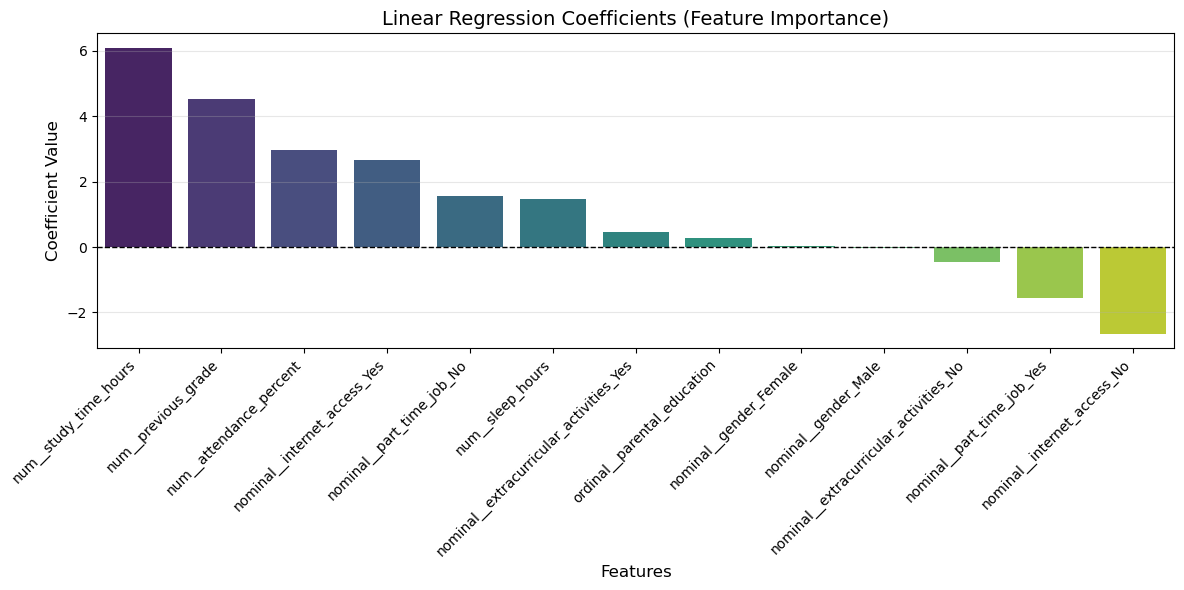

In [62]:
feature_names = preprocess_2.get_feature_names_out()
coef_values = model_2.coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef_values
})

coef_df = coef_df.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=coef_df,
    x='Feature',
    y='Coefficient',
    hue='Feature',          
    palette='viridis',
    legend=False ,
    estimator = 'sum'
)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.title('Linear Regression Coefficients (Feature Importance)', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Students with internet score +2.6 marks higher than no internet while no internet decreases by -2.6

Each level increase (High School → Bachelors → Masters → PhD) → +0.1 marks

## Perfomance measure for classification

Because the dataset already have 90% 1 labels the accuracy of 90% is not informative

In [63]:
scores = cross_val_score(model, X_train_transformed ,y_train , scoring = 'accuracy' , cv  = 5)
scores.mean() , scores.std()

(np.float64(0.9137500000000001), np.float64(0.015000000000000029))

In [53]:
df['pass'].value_counts(normalize = True)

pass
1    0.899
0    0.101
Name: proportion, dtype: float64

The accuracy does not add the information 

also the cross_val_score did not stratify the folds maybe biased not exact ratio of class

The skfods maintains the class ratio during the sampling

In [64]:
from sklearn.model_selection import StratifiedKFold
skfolds = StratifiedKFold (random_state = 26 , n_splits = 5, shuffle=True )
scores = cross_val_score( model, X_train_transformed ,y_train , scoring = 'accuracy' ,  cv = skfolds) 
scores.mean()

np.float64(0.9125)

In [65]:
model.score( preprocess.transform(X_test) , y_test)

0.935

Training Data

   ↓
   
preprocessor.fit_transform(X_train)   ← Learns mean/std and transforms

   ↓
   
Training is done
  
   ↓
   


   
Test Data (unseen)

   ↓
   
preprocessor.transform(X_test)   ← Only applies the SAME transformation

   ↓
   
   
No learning happens on test data

In [79]:
from sklearn.model_selection import cross_val_predict

prediction = cross_val_predict(model, X_train_transformed ,y_train , cv = skfolds)

In [80]:
np.count_nonzero( prediction == 1 )

761

In [81]:
np.count_nonzero( y_train == 1) 

719

In [84]:
np.count_nonzero( prediction == 0 ) 

39

In [85]:
np.count_nonzero( prediction == 1 ) 

761

So here the model is biased towards the class 1 it did count failures of class 0 as class 1

The confusion matrix solves this and displays how many model mistakenly predicted class 1 which was class 0


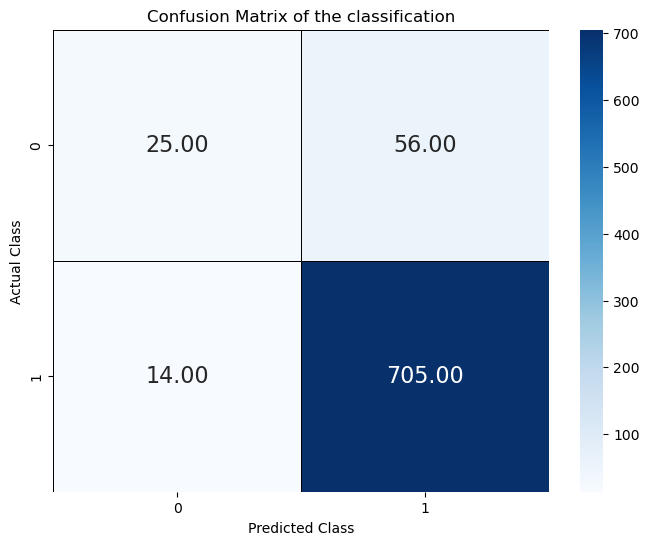

In [111]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(y_train , prediction)

plt.figure(figsize = (8,6))
sns.heatmap( mat,  annot =  True , fmt= '.2f' ,linewidth = 0.4 , linecolor='black', cmap = 'Blues', annot_kws={'size': 16}) 
plt.title('Confusion Matrix of the classification')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

In [100]:
np.diag(mat).sum() / np.sum(mat)   #Accuracy

np.float64(0.9125)

Each row in a confusion matrix represents an actual class, while each column repre‐
sents a predicted class

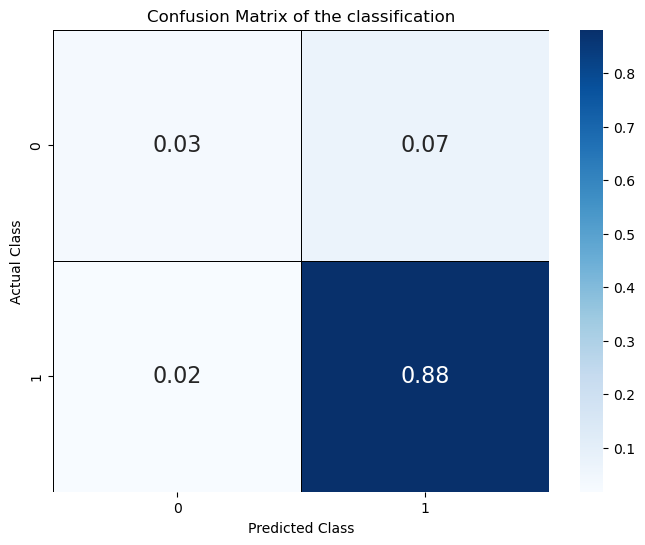

In [112]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(y_train , prediction , normalize = 'all')

plt.figure(figsize = (8,6))
sns.heatmap( mat,  annot =  True , fmt= '.2f' ,linewidth = 0.4 , linecolor='black', cmap = 'Blues', annot_kws={'size': 16}) 
plt.title('Confusion Matrix of the classification')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

the diagonal entries are true negative and true postive, the off diagonal are false negative and false positive

Precision is the percentage of positive predictions that were actually correct.


precision is the accuracy of positive prediction

= ( TP ) / ( FP + TP ) 

In [113]:
705 /(705 + 56)

0.926412614980289

In [115]:
from sklearn.metrics import precision_score

precision_score(y_train, prediction, pos_label = 1) 

0.926412614980289

In [117]:
#or precision is the accuracy of correct prediction

precision_score(y_train, prediction, pos_label = 0) 

0.6410256410256411

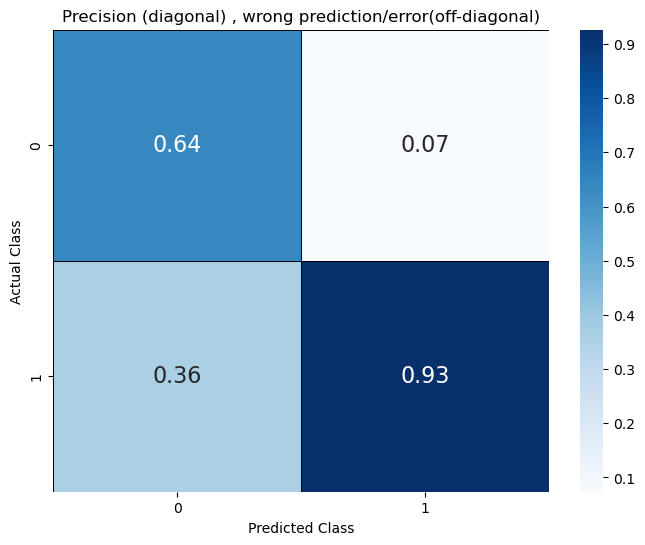

In [126]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(y_train , prediction , normalize = 'pred')

plt.figure(figsize = (8,6))
sns.heatmap( mat,  annot =  True , fmt= '.2f' ,linewidth = 0.4 , linecolor='black', cmap = 'Blues', annot_kws={'size': 16}) 
plt.title('Precision (diagonal) , wrong prediction/error(off-diagonal)')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

Given model prediction of 0 there are 36% chance that the actual person was 1(pass)

The diagonal entries tells the precision , columns sums =1 

Also it is also a congentinal table when normalize = 'all' it gives us joint probability

and when normalize = 'pred' it gives conditional probability ( Like Given prediction what is the probability of actual class)

---
**Recall**: does thing in reverse it tells thes probability of prediction given the actual class where row sum are equal of 1

= TP /( TP + FN ) 

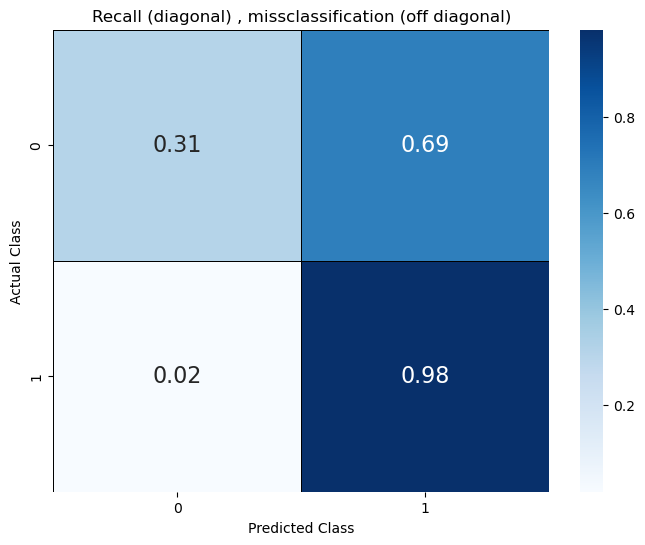

In [125]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(y_train , prediction , normalize = 'true')

plt.figure(figsize = (8,6))
sns.heatmap( mat,  annot =  True , fmt= '.2f' ,linewidth = 0.4 , linecolor='black', cmap = 'Blues', annot_kws={'size': 16}) 
plt.title('Recall (diagonal) , missclassification (off diagonal)')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

Given that the student failed (0) there are 69% chance that the model will make him classify as pass

This table is also a bayes thoerem if done with the probability concepts


In [138]:
from sklearn.metrics import recall_score , precision_score

recall_score(y_train  , prediction , pos_label=0 ),precision_score(y_train , prediction , pos_label = 0 ) 

(0.30864197530864196, 0.6410256410256411)

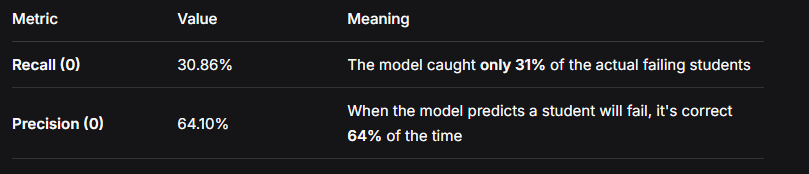

In [139]:
recall_score(y_train  , prediction , pos_label=1 ),precision_score(y_train , prediction , pos_label = 1 )

(0.980528511821975, 0.926412614980289)

---
**F1 score** : The F1
 score is
the harmonic mean of precision and recall Whereas the regular mean treats all values equally, the harmonic mean gives much more weight to low values.
As a result, the classifier will only get a high F1
 score if both recall and precision are
high.

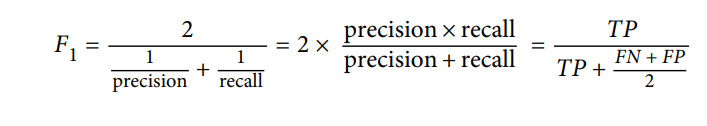

In [143]:
from sklearn.metrics import f1_score
f1_score(y_train , prediction , pos_label = 0 )

0.4166666666666667

The model is very weak of identifying the fail students it might make them pass or not identify them,

The reason is that because model was trained on 10% people who failed the exam that is why it has bad f1score for detecting the class 0

In [144]:
f1_score(y_train , prediction , pos_label = 1 )

0.9527027027027027